# Render annotations
In this notebook, we are going to come up with a way to render annotations that allows for irregular patch size.

Note - this does not require the slides to be loaded.

Ideally we will use a spatial index.

In [1]:
patch_size = 224
magnification_level = 1  # x20

In [2]:
# first we load in an annotation
from pathlib import Path

from histokit.data.annotations import get_annotation_loader, AnnotationSet
from histokit.data.schema import DatasetSchema

dataset_path = Path('../data/icaird/cervical_mini')
load_annotation = get_annotation_loader('geojson')
schema = DatasetSchema.from_json(dataset_path / 'labels.json').annotations
annotation_regions = load_annotation(dataset_path / 'annotations/IC-CX-00003-01.geojson', schema)
annotation_set = AnnotationSet(annotation_regions, schema)

{'name': 'High Grade', 'colorRGB': -8802071}
{'name': 'High Grade', 'colorRGB': -8802071}
{'name': 'High Grade', 'colorRGB': -8802071}
{'name': 'High Grade', 'colorRGB': -8802071}
{'name': 'High Grade', 'colorRGB': -8802071}
{'name': 'High Grade', 'colorRGB': -8802071}
{'name': 'High Grade', 'colorRGB': -8802071}
{'name': 'High Grade', 'colorRGB': -8802071}
{'name': 'High Grade', 'colorRGB': -8802071}
{'name': 'High Grade', 'colorRGB': -8802071}
{'name': 'High Grade', 'colorRGB': -8802071}
{'name': 'High Grade', 'colorRGB': -8802071}


In [3]:
minx, miny, maxx, maxy = annotation_set.bounds
minx, miny, maxx, maxy

(14266.0, 2100.0, 30727.0, 36405.0)

Now we have the bounding box, we can work out the size of the area of the annotations in patches.

Note that all annotation coords are assumed to be at level 0.
So we need to work out the patch size in level 0 pixels.

In [4]:
def patch_size_at_zero(patch_size: int, mag_level: int) -> int:
    return 2**mag_level * patch_size


def bounding_box_to_patch_grid(
    bounds: tuple[float, float, float, float],
    patch_size: int,
    mag_level: int,
) -> tuple[int, int, int, int]:
    patch_size_zero = patch_size_at_zero(patch_size, mag_level)
    print(f"Patch size at magnification level {mag_level}: {patch_size_zero}")
    minx, miny, maxx, maxy = bounds
    x_start = int(minx // patch_size_zero)
    y_start = int(miny // patch_size_zero)
    x_end = int(maxx // patch_size_zero)
    y_end = int(maxy // patch_size_zero)
    return x_start, y_start, x_end, y_end

grid = bounding_box_to_patch_grid(annotation_set.bounds, patch_size, magnification_level)
grid

Patch size at magnification level 1: 448


(31, 4, 68, 81)

In [7]:
from histokit.utils.geometry import Shape


shape = Shape(grid[3], grid[2])
factor = minx / grid[0]
feature_map = annotation_set.render(shape, factor)
feature_map.shape

(81, 68)

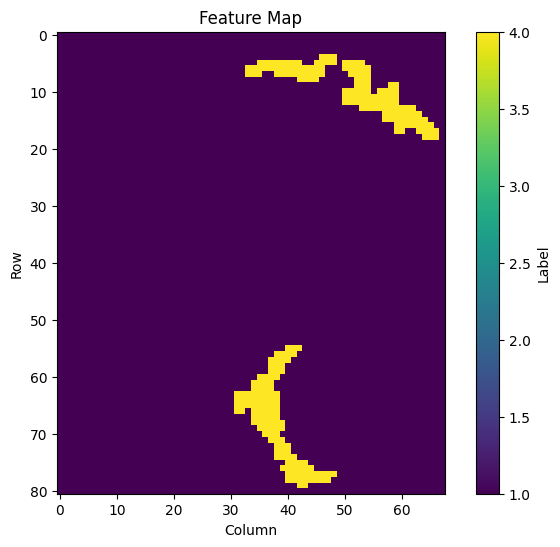

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(feature_map, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Label')
plt.title('Feature Map')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

In [ ]:
from histokit.data.slides import get_slide_cls

slide_cls = get_slide_cls('openslide')
slide_path = dataset_path / 'slides' / 'IC-CX-00003-01.ome.tiff'
with slide_cls(slide_path) as slide:
    slide_width, slide_ = slide.dimensions[0]